In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pennylane as qp
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Setting of the main hyper-parameters of the model


In [3]:
n_epochs = 30   # Number of optimization epochs
n_layers = 1    # Number of random layers
n_train = 50    # Size of the train dataset
n_test = 30     # Size of the test dataset

SAVE_PATH = ""  # Data saving folder
PREPROCESS = True           # If False, skip quantum processing and load data from SAVE_PATH
np.random.seed(0)           # Seed for NumPy random number generator
tf.random.set_seed(0)       # Seed for TensorFlow random number generator

# Loading of the MNIST dataset
We import the MNIST dataset from Keras. To speedup the evaluation of this demo we use only a small number of training and test images. Obviously, better results are achievable when using the full dataset.




In [4]:
mnist_dataset = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist_dataset.load_data()

# Reduce dataset size
train_images = train_images[:n_train]
train_labels = train_labels[:n_train]
test_images = test_images[:n_test]
test_labels = test_labels[:n_test]

# Normalize pixel values within 0 and 1
train_images = train_images / 255
test_images = test_images / 255

# Add extra dimension for convolution channels
train_images = np.array(train_images[..., tf.newaxis], requires_grad=False)
test_images = np.array(test_images[..., tf.newaxis], requires_grad=False)

# Quantum circuit as a convolution kernel
---------------------------------------

We follow the scheme described in the introduction and represented in the figure at the top
of this demo.

We initialize a PennyLane ``default.qubit`` device, simulating a system of :math:`4` qubits.
The associated ``qnode`` represents the quantum circuit consisting of:

1. an embedding layer of local :math:`R_y` rotations (with angles scaled by a factor of :math:`\pi`);

2. a random circuit of ``n_layers``;

3. a final measurement in the computational basis, estimating :math:`4` expectation values.





In [5]:
dev = qp.device("default.qubit", wires=4)
# Random circuit parameters
rand_params = np.random.uniform(high=2 * np.pi, size=(n_layers, 4))

@qp.qnode(dev)
def circuit(phi):
    # Encoding of 4 classical input values
    for j in range(4):
        qp.RY(np.pi * phi[j], wires=j)

    # Random quantum circuit
    RandomLayers(rand_params, wires=list(range(4)))

    # Measurement producing 4 classical output values
    return [qp.expval(qp.PauliZ(j)) for j in range(4)]

# The next function defines the convolution scheme:

1. the image is divided into squares of :math:`2 \times 2` pixels;

2. each square is processed by the quantum circuit;

3. the :math:`4` expectation values are mapped into :math:`4` different
    channels of a single output pixel.

 .. note::
       This process halves the resolution of the input image. In the
       standard language of CNN, this would correspond to a convolution
       with a :math:`2 \times 2` *kernel* and a *stride* equal to :math:`2.`


In [6]:
def quanv(image):
    """Convolves the input image with many applications of the same quantum circuit."""
    out = np.zeros((14, 14, 4))

    # Loop over the coordinates of the top-left pixel of 2X2 squares
    for j in range(0, 28, 2):
        for k in range(0, 28, 2):
            # Process a squared 2x2 region of the image with a quantum circuit
            q_results = circuit(
                [
                    image[j, k, 0],
                    image[j, k + 1, 0],
                    image[j + 1, k, 0],
                    image[j + 1, k + 1, 0]
                ]
            )
            # Assign expectation values to different channels of the output pixel (j/2, k/2)
            for c in range(4):
                out[j // 2, k // 2, c] = q_results[c]
    return out

# Quantum pre-processing of the dataset


Since we are not going to train the quantum convolution layer, it is more
efficient to apply it as a "pre-processing" layer to all the images of our dataset.
Later an entirely classical model will be directly trained and tested on the
pre-processed dataset, avoiding unnecessary repetitions of quantum computations.

The pre-processed images will be saved in the folder ``SAVE_PATH``.
Once saved, they can be directly loaded by setting ``PREPROCESS = False``,
otherwise the quantum convolution is evaluated at each run of the code.


In [7]:
if PREPROCESS == True:
    q_train_images = []
    print("Quantum pre-processing of train images:")
    for idx, img in enumerate(train_images):
        print("{}/{}        ".format(idx + 1, n_train), end="\r")
        q_train_images.append(quanv(img))
    q_train_images = np.asarray(q_train_images)

    q_test_images = []
    print("\nQuantum pre-processing of test images:")
    for idx, img in enumerate(test_images):
        print("{}/{}        ".format(idx + 1, n_test), end="\r")
        q_test_images.append(quanv(img))
    q_test_images = np.asarray(q_test_images)

    # Save pre-processed images
    np.save(SAVE_PATH + "q_train_images.npy", q_train_images)
    np.save(SAVE_PATH + "q_test_images.npy", q_test_images)


# Load pre-processed images
q_train_images = np.load(SAVE_PATH + "q_train_images.npy")
q_test_images = np.load(SAVE_PATH + "q_test_images.npy")


Quantum pre-processing of train images:
50/50        
Quantum pre-processing of test images:


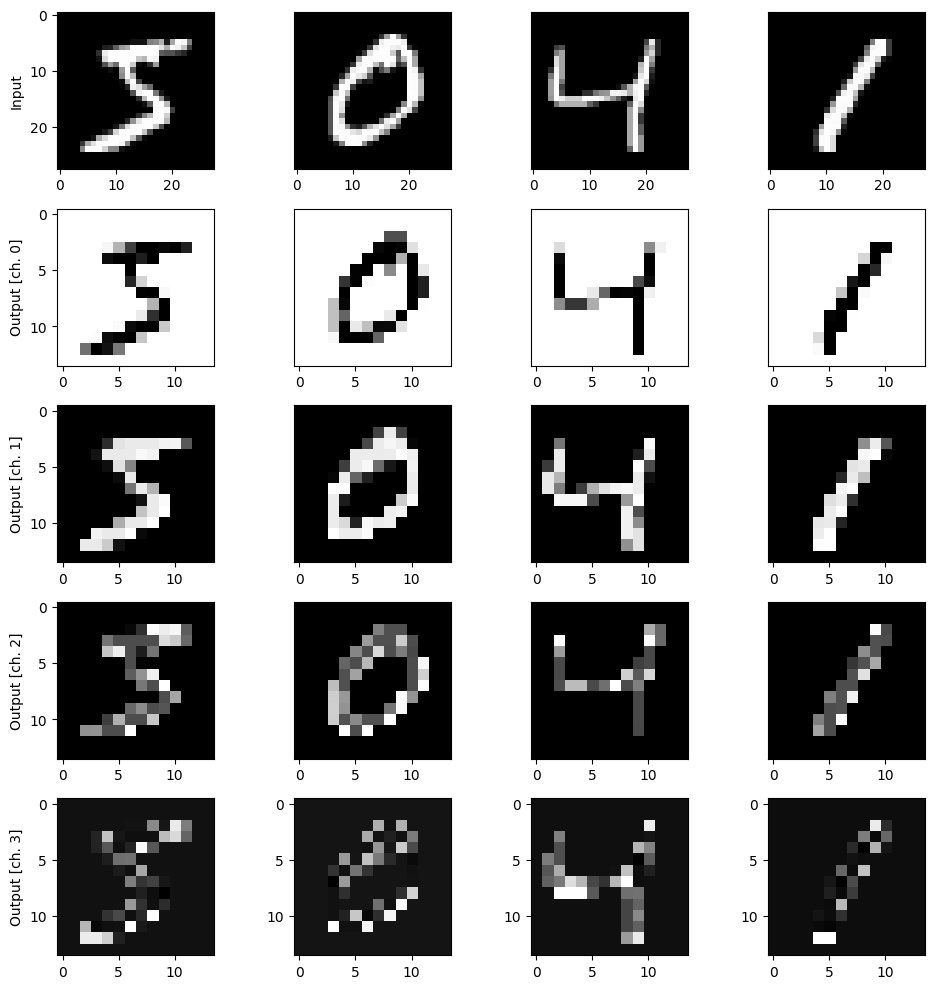

In [8]:
n_samples = 4
n_channels = 4
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(10, 10))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_images[k, :, :, 0], cmap="gray")

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images[k, :, :, c], cmap="gray")

plt.tight_layout()
plt.show()

# Hybrid quantum-classical model
------------------------------

After the application of the quantum convolution layer we feed the resulting
features into a classical neural network that will be trained to classify
the :math:`10` different digits of the MNIST dataset.

We use a very simple model: just a fully connected layer with
10 output nodes with a final *softmax* activation function.

The model is compiled with a *stochastic-gradient-descent* optimizer,
and a *cross-entropy* loss function.


In [9]:
def MyModel():
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Flatten(),
        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Training

We first initialize an instance of the model, then we train and validate
it with the dataset that has been already pre-processed by a quantum convolution.

In [10]:
q_model = MyModel()

q_history = q_model.fit(
    q_train_images,
    train_labels,
    validation_data=(q_test_images, test_labels),
    batch_size=4,
    epochs=n_epochs,
    verbose=2,
)

Epoch 1/30
13/13 - 1s - 51ms/step - accuracy: 0.0600 - loss: 2.8348 - val_accuracy: 0.2333 - val_loss: 2.2697
Epoch 2/30
13/13 - 0s - 4ms/step - accuracy: 0.3000 - loss: 2.0053 - val_accuracy: 0.3333 - val_loss: 2.0452
Epoch 3/30
13/13 - 0s - 4ms/step - accuracy: 0.4400 - loss: 1.6905 - val_accuracy: 0.4667 - val_loss: 1.8754
Epoch 4/30
13/13 - 0s - 4ms/step - accuracy: 0.6600 - loss: 1.3806 - val_accuracy: 0.5000 - val_loss: 1.7588
Epoch 5/30
13/13 - 0s - 4ms/step - accuracy: 0.7800 - loss: 1.1473 - val_accuracy: 0.5333 - val_loss: 1.6422
Epoch 6/30
13/13 - 0s - 4ms/step - accuracy: 0.8800 - loss: 0.9604 - val_accuracy: 0.6333 - val_loss: 1.5464
Epoch 7/30
13/13 - 0s - 4ms/step - accuracy: 0.9200 - loss: 0.8090 - val_accuracy: 0.6333 - val_loss: 1.4717
Epoch 8/30
13/13 - 0s - 4ms/step - accuracy: 0.9400 - loss: 0.6891 - val_accuracy: 0.7000 - val_loss: 1.4087
Epoch 9/30
13/13 - 0s - 4ms/step - accuracy: 0.9400 - loss: 0.5915 - val_accuracy: 0.7000 - val_loss: 1.3538
Epoch 10/30
13/13 

In order to compare the results achievable with and without the quantum convolution layer,
we initialize also a "classical" instance of the model that will be directly trained
and validated with the raw MNIST images (i.e., without quantum pre-processing).

In [11]:
c_model = MyModel()

c_history = c_model.fit(
    train_images,
    train_labels,
    validation_data=(test_images, test_labels),
    batch_size=4,
    epochs=n_epochs,
    verbose=2,
)

Epoch 1/30
13/13 - 1s - 42ms/step - accuracy: 0.0600 - loss: 2.4594 - val_accuracy: 0.1000 - val_loss: 2.3591
Epoch 2/30
13/13 - 0s - 4ms/step - accuracy: 0.4000 - loss: 2.0183 - val_accuracy: 0.1333 - val_loss: 2.1704
Epoch 3/30
13/13 - 0s - 4ms/step - accuracy: 0.5800 - loss: 1.7191 - val_accuracy: 0.2667 - val_loss: 2.0110
Epoch 4/30
13/13 - 0s - 4ms/step - accuracy: 0.7400 - loss: 1.4750 - val_accuracy: 0.3667 - val_loss: 1.8703
Epoch 5/30
13/13 - 0s - 4ms/step - accuracy: 0.8000 - loss: 1.2704 - val_accuracy: 0.4667 - val_loss: 1.7492
Epoch 6/30
13/13 - 0s - 4ms/step - accuracy: 0.9200 - loss: 1.0994 - val_accuracy: 0.5333 - val_loss: 1.6475
Epoch 7/30
13/13 - 0s - 4ms/step - accuracy: 0.9600 - loss: 0.9572 - val_accuracy: 0.5333 - val_loss: 1.5623
Epoch 8/30
13/13 - 0s - 4ms/step - accuracy: 0.9600 - loss: 0.8387 - val_accuracy: 0.5667 - val_loss: 1.4904
Epoch 9/30
13/13 - 0s - 4ms/step - accuracy: 0.9800 - loss: 0.7395 - val_accuracy: 0.6333 - val_loss: 1.4292
Epoch 10/30
13/13 

# Results

We can finally plot the test accuracy and the test loss with respect to the
number of training epochs.

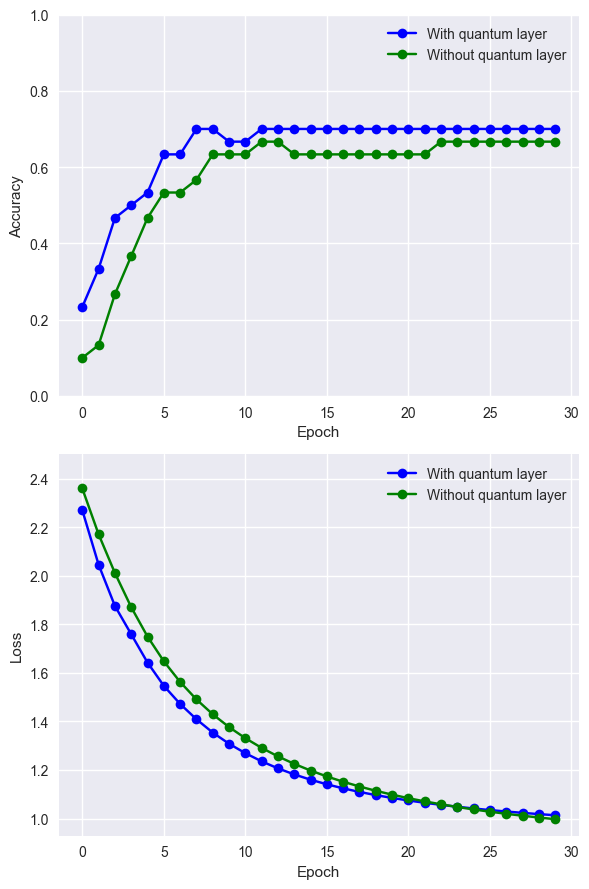

In [12]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))

ax1.plot(q_history.history["val_accuracy"], "-ob", label="With quantum layer")
ax1.plot(c_history.history["val_accuracy"], "-og", label="Without quantum layer")
ax1.set_ylabel("Accuracy")
ax1.set_ylim([0, 1])
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(q_history.history["val_loss"], "-ob", label="With quantum layer")
ax2.plot(c_history.history["val_loss"], "-og", label="Without quantum layer")
ax2.set_ylabel("Loss")
ax2.set_ylim(top=2.5)
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.show()
